# SAE Pipeline — Smoke Test on Mock Data

This notebook runs the full SAE (Sparse Autoencoder) pipeline on synthetic data
to verify that all stages work correctly end-to-end.

**Mock data** in `data/mock/`:
- `visual_embeddings.pt` — 200 random vectors (512-dim), simulating BiomedCLIP output
- `train_embeddings.pt` — 160 vectors (80% split)
- `test_embeddings.pt` — 40 vectors (20% split)
- `text_vocab_embeddings.pt` — 100 vectors (simulating medical vocabulary)
- `vocabulary.json` — 100 medical terms

**Pipeline stages:**
1. SAE Training (2 seeds, 100 steps)
2. Concept Naming
3. Generate Explanations
4. Stability Analysis
5. Visualization

## 0. Setup & Configuration

In [1]:
import sys
import json
import shutil
from pathlib import Path

import torch

# Resolve project root (3 levels up from this notebook)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"}')

Project root: /Users/marcantoniolopez/Documents/github/xai-project-5
PyTorch: 2.12.0
Device: mps


In [2]:
import config

# Override config to use mock data and reduced parameters
MOCK_DIR = PROJECT_ROOT / 'data' / 'mock'
MOCK_MODELS_DIR = PROJECT_ROOT / 'models' / 'mock'
MOCK_RESULTS_DIR = PROJECT_ROOT / 'results' / 'mock'

# Override paths
config.paths.visual_embeddings_path = MOCK_DIR / 'visual_embeddings.pt'
config.paths.train_embeddings_path = MOCK_DIR / 'train_embeddings.pt'
config.paths.test_embeddings_path = MOCK_DIR / 'test_embeddings.pt'
config.paths.vocab_embeddings_path = MOCK_DIR / 'text_vocab_embeddings.pt'
config.paths.vocab_labels_path = MOCK_DIR / 'vocabulary.json'
config.paths.models_dir = MOCK_MODELS_DIR
config.paths.results_dir = MOCK_RESULTS_DIR
config.paths.figures_dir = MOCK_RESULTS_DIR / 'figures'

# Override SAE for speed (100 steps, 2 seeds)
object.__setattr__(config.sae, 'steps', 100)
object.__setattr__(config.sae, 'warmup_steps', 10)
object.__setattr__(config.sae, 'batch_size', 32)

# Only 2 seeds for speed
object.__setattr__(config.training, 'seeds', (42, 123))
object.__setattr__(config.training, 'primary_seed', 42)

print('=== Mock Configuration ===')
print(f'Mock data:   {MOCK_DIR}')
print(f'Mock models: {MOCK_MODELS_DIR}')
print(f'Mock results:{MOCK_RESULTS_DIR}')
print(f'Steps: {config.sae.steps}, Seeds: {config.training.seeds}')
print(f'Batch size: {config.sae.batch_size}, k: {config.sae.k}')

=== Mock Configuration ===
Mock data:   /Users/marcantoniolopez/Documents/github/xai-project-5/data/mock
Mock models: /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock
Mock results:/Users/marcantoniolopez/Documents/github/xai-project-5/results/mock
Steps: 100, Seeds: (42, 123)
Batch size: 32, k: 32


In [3]:
# Verify mock data exists
mock_files = [
    ('visual_embeddings.pt', MOCK_DIR / 'visual_embeddings.pt'),
    ('train_embeddings.pt', MOCK_DIR / 'train_embeddings.pt'),
    ('test_embeddings.pt', MOCK_DIR / 'test_embeddings.pt'),
    ('text_vocab_embeddings.pt', MOCK_DIR / 'text_vocab_embeddings.pt'),
    ('vocabulary.json', MOCK_DIR / 'vocabulary.json'),
]

print('=== Mock Data Verification ===')
all_ok = True
for name, path in mock_files:
    exists = path.exists()
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {name}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('Mock data missing! See README to generate them.')

# Show shapes
print('\n=== Shapes ===')
for name, path in mock_files:
    if path.suffix == '.pt':
        t = torch.load(path, map_location='cpu', weights_only=True)
        print(f'  {name}: {t.shape}')
    else:
        with open(path) as f:
            data = json.load(f)
        print(f'  {name}: {len(data)} items')

=== Mock Data Verification ===
  [OK] visual_embeddings.pt
  [OK] train_embeddings.pt
  [OK] test_embeddings.pt
  [OK] text_vocab_embeddings.pt
  [OK] vocabulary.json

=== Shapes ===
  visual_embeddings.pt: torch.Size([200, 512])
  train_embeddings.pt: torch.Size([160, 512])
  test_embeddings.pt: torch.Size([40, 512])
  text_vocab_embeddings.pt: torch.Size([100, 512])
  vocabulary.json: 100 items


## 1. SAE Training

Trains 2 SAE models (seed 42, 123) with only 100 steps.
We don't expect convergence — the goal is to verify the code runs correctly.

In [4]:
from autoencoder.sae_module import SAEManager

# Clean up previous models
if MOCK_MODELS_DIR.exists():
    shutil.rmtree(MOCK_MODELS_DIR)
    print(f'Removed: {MOCK_MODELS_DIR}')

trained_models = {}

for seed in config.training.seeds:
    print(f'\n--- Training seed={seed} ---')
    
    mgr = SAEManager({
        'device': config.hardware.device,
        'activation_dim': config.sae.activation_dim,
        'dict_size': config.sae.dict_size,
        'k': config.sae.k,
        'warmup_steps': config.sae.warmup_steps,
    })
    
    model_dir = mgr.train(
        embeddings_path=config.paths.train_embeddings_path,
        seed=seed,
        save_dir=MOCK_MODELS_DIR,
        steps=config.sae.steps,
        batch_size=config.sae.batch_size,
    )
    
    trained_models[seed] = model_dir
    print(f'Saved: {model_dir}')

/Users/marcantoniolopez/Documents/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removed: /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock

--- Training seed=42 ---


Calculating norm factor: 101it [00:00, 8882.14it/s]             


Average mean squared norm: 518.5968627929688
Norm factor: 22.772722244262695


  3%|▎         | 3/100 [00:00<00:04, 23.69it/s]

...

Average mean squared norm: 518.4823608398438
Norm factor: 22.77020835876465


  3%|▎         | 3/100 [00:00<00:03, 27.64it/s]

Step 0: L0 = 32.0, frac_variance_explained = 0.2615455985069275


100%|██████████| 100/100 [00:03<00:00, 29.12it/s]

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed123


In [5]:
# Sanity checks on trained models
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)
print(f'Test embeddings: {test_emb.shape}')
print()

for seed, model_dir in trained_models.items():
    mgr = SAEManager({'device': 'cpu'})
    mgr.load(model_dir)
    
    mse = mgr.compute_reconstruction_mse(test_emb)
    sparsity = mgr.compute_sparsity_metrics(test_emb)
    
    print(f'Seed {seed}:')
    print(f'  MSE:              {mse:.6f}')
    print(f'  L0 mean:          {sparsity["l0_mean"]:.1f} (expected: {config.sae.k})')
    print(f'  Dead features:    {sparsity["dead_features_pct"]:.1f}%')
    print(f'  Dict utilization: {sparsity["dict_utilization_pct"]:.1f}%')
    print()

Test embeddings: torch.Size([40, 512])

Seed 42:
  MSE:              0.746328
  L0 mean:          32.0 (expected: 32)
  Dead features:    73.8%
  Dict utilization: 26.2%

Seed 123:
  MSE:              0.742350
  L0 mean:          32.0 (expected: 32)
  Dead features:    73.6%
  Dict utilization: 26.4%



In [ ]:
# 1.3 Training & Test Loss Curves
# Train a fresh SAE with checkpoints to plot loss over training steps
import shutil
from dictionary_learning.trainers.top_k import AutoEncoderTopK, TopKTrainer
from dictionary_learning.training import trainSAE

CURVE_DIR = MOCK_MODELS_DIR / 'loss_curve'
if CURVE_DIR.exists():
    shutil.rmtree(CURVE_DIR)

train_emb = torch.load(config.paths.train_embeddings_path, map_location='cpu', weights_only=True)
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)

# Train with save_steps to get checkpoints
n_steps = 100
checkpoint_steps = list(range(0, n_steps, 10))  # every 10 steps

def batch_gen():
    while True:
        perm = torch.randperm(len(train_emb))
        for i in range(0, len(perm), 32):
            yield train_emb[perm[i:i+32]]

trainer_cfg = {
    "trainer": TopKTrainer,
    "activation_dim": 512,
    "dict_size": 4096,
    "k": 32,
    "steps": n_steps,
    "layer": 0,
    "lm_name": "mock",
    "lr": 3e-4,
    "warmup_steps": 10,
    "decay_start": 80,
    "seed": 42,
    "device": "cpu",
}

trainSAE(
    data=batch_gen(),
    trainer_configs=[trainer_cfg],
    steps=n_steps,
    save_dir=str(CURVE_DIR),
    save_steps=checkpoint_steps,
    log_steps=100,
    device="cpu",
    normalize_activations=True,
    verbose=False,
)
print(f'Trained with {len(checkpoint_steps)} checkpoints')

ImportError: cannot import name 'get_norm_factor' from 'dictionary_learning.utils' (/Users/marcantoniolopez/Documents/github/xai-project-5/.venv/lib/python3.12/site-packages/dictionary_learning/utils.py)

In [ ]:
# Load each checkpoint and compute train/test MSE
import numpy as np

checkpoint_dir = CURVE_DIR / 'trainer_0' / 'checkpoints'
final_path = CURVE_DIR / 'trainer_0' / 'ae.pt'

train_losses = []
test_losses = []
steps_recorded = []

for step in checkpoint_steps:
    ckpt_path = checkpoint_dir / f'ae_{step}.pt'
    if ckpt_path.exists():
        ae = AutoEncoderTopK(512, 4096, 32)
        ae.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=True))
        ae.eval()
        with torch.no_grad():
            train_recon = ae(train_emb)[0]
            test_recon = ae(test_emb)[0]
            train_mse = ((train_emb - train_recon) ** 2).mean().item()
            test_mse = ((test_emb - test_recon) ** 2).mean().item()
        train_losses.append(train_mse)
        test_losses.append(test_mse)
        steps_recorded.append(step)

# Also evaluate final model
ae = AutoEncoderTopK(512, 4096, 32)
ae.load_state_dict(torch.load(final_path, map_location='cpu', weights_only=True))
ae.eval()
with torch.no_grad():
    train_recon = ae(train_emb)[0]
    test_recon = ae(test_emb)[0]
    train_mse_final = ((train_emb - train_recon) ** 2).mean().item()
    test_mse_final = ((test_emb - test_recon) ** 2).mean().item()
train_losses.append(train_mse_final)
test_losses.append(test_mse_final)
steps_recorded.append(n_steps)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps_recorded, train_losses, 'b-o', label='Train MSE', markersize=4)
ax.plot(steps_recorded, test_losses, 'r-s', label='Test MSE', markersize=4)
ax.set_xlabel('Training Step')
ax.set_ylabel('MSE (Reconstruction Loss)')
ax.set_title('Training & Test Loss Curve (SAE, 100 steps, mock data)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Step 0  → Train MSE: {train_losses[0]:.4f}, Test MSE: {test_losses[0]:.4f}')
print(f'Step {n_steps} → Train MSE: {train_losses[-1]:.4f}, Test MSE: {test_losses[-1]:.4f}')
print(f'Saved: {FIGURES_DIR / "loss_curve.png"}')

## 2. Concept Naming

Assigns medical names to each of the 4096 SAE features using cosine similarity
between the decoder weights and the vocabulary embeddings.

In [6]:
# Load vocabulary
with open(config.paths.vocab_labels_path) as f:
    vocab_labels = json.load(f)

vocab_embeddings = torch.load(
    config.paths.vocab_embeddings_path, map_location='cpu', weights_only=True
)

print(f'Vocabulary: {len(vocab_labels)} terms')
print(f'Vocab embeddings: {vocab_embeddings.shape}')
print(f'First 10 terms: {vocab_labels[:10]}')

Vocabulary: 100 terms
Vocab embeddings: torch.Size([100, 512])
First 10 terms: ['cardiomegaly', 'pleural_effusion', 'pneumothorax', 'consolidation', 'atelectasis', 'pulmonary_edema', 'pneumonia', 'emphysema', 'fibrosis', 'nodule']


In [7]:
# Naming with the primary model (seed 42)
primary_model_dir = MOCK_MODELS_DIR / f'sae_seed{config.training.primary_seed}'

mgr = SAEManager({'device': 'cpu'})
mgr.load(primary_model_dir)

concept_names = mgr.name_concepts(
    vocab_embeddings, vocab_labels, top_n=config.explanation.concept_top_n
)

# Statistics
scores = [v['score'] for v in concept_names.values()]
print(f'Features named: {len(concept_names)}')
print(f'Mean score:     {sum(scores)/len(scores):.4f}')
print(f'Min/Max score:  {min(scores):.4f} / {max(scores):.4f}')

# Top-10
print('\nTop-10 concepts by score:')
sorted_concepts = sorted(concept_names.items(), key=lambda x: x[1]['score'], reverse=True)
for feat_id, info in sorted_concepts[:10]:
    print(f'  Feature {feat_id:>4}: {info["name"]:30s} (score={info["score"]:.4f})')

Features named: 4096
Mean score:     0.1108
Min/Max score:  0.0618 / 0.2068

Top-10 concepts by score:
  Feature 4090: medical_concept_48             (score=0.2068)
  Feature 2322: medical_concept_50             (score=0.2058)
  Feature  344: medical_concept_4              (score=0.1862)
  Feature  623: medical_concept_56             (score=0.1854)
  Feature  199: medical_concept_64             (score=0.1820)
  Feature 2164: cardiomegaly                   (score=0.1804)
  Feature 3631: medical_concept_61             (score=0.1797)
  Feature  875: medical_concept_8              (score=0.1742)
  Feature 1076: medical_concept_4              (score=0.1734)
  Feature 2336: medical_concept_8              (score=0.1722)


In [8]:
# Save concept_names.json
MOCK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
concept_names_path = MOCK_RESULTS_DIR / 'concept_names.json'

with open(concept_names_path, 'w') as f:
    json.dump(concept_names, f, indent=2, ensure_ascii=False)

print(f'Saved: {concept_names_path}')
print(f'Size: {concept_names_path.stat().st_size / 1024:.1f} KB')

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/concept_names.json
Size: 1532.0 KB


## 3. Generate Explanations

For each test image, extracts the top-k activated concepts
and generates a structured pseudo-report for the LLM Judge.

In [9]:
from autoencoder.generate_explanations import generate_explanation

# Carica test embeddings e concept_names
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)

with open(concept_names_path) as f:
    concept_names_json = json.load(f)

# Estrai top concepts per ogni sample del test set
mgr = SAEManager({'device': 'cpu'})
mgr.load(primary_model_dir)

all_top_concepts = mgr.get_top_concepts(test_emb, n=config.explanation.explanation_top_n)
print(f'Test samples: {len(all_top_concepts)}')
print(f'Concepts per sample: {config.explanation.explanation_top_n}')

18:31:11 | INFO | Loaded SAE from /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Test samples: 40
Concepts per sample: 5


In [10]:
# Generate explanations
explanations = []
for idx, top_concepts in enumerate(all_top_concepts):
    explanation = generate_explanation(top_concepts, concept_names_json)
    explanation['sample_idx'] = idx
    explanations.append(explanation)

print(f'Explanations generated: {len(explanations)}')
print()

# Show first 3 pseudo-reports
print('=== Sample Pseudo-Reports ===')
for i, exp in enumerate(explanations[:3]):
    print(f'\nSample {i}:')
    print(f'  Report: {exp["pseudo_report"]}')
    print(f'  Findings: {len(exp["findings"])} concepts')
    for f in exp['findings'][:3]:
        print(f'    - {f["concept"]} (act={f["activation"]:.3f}, conf={f["naming_confidence"]:.3f})')

Explanations generated: 40

=== Sample Pseudo-Reports ===

Sample 0:
  Report: The model identifies the following visual concepts in this radiograph: mediastinal_widening, hilar_enlargement, medical_concept_29, medical_concept_72, medical_concept_67. The dominant concept is 'mediastinal_widening' (activation=3.671).
  Findings: 5 concepts
    - mediastinal_widening (act=3.671, conf=0.118)
    - hilar_enlargement (act=3.322, conf=0.105)
    - medical_concept_29 (act=3.304, conf=0.103)

Sample 1:
  Report: The model identifies the following visual concepts in this radiograph: medical_concept_75, medical_concept_67, consolidation, medical_concept_76, pneumothorax. The dominant concept is 'medical_concept_75' (activation=3.246).
  Findings: 5 concepts
    - medical_concept_75 (act=3.246, conf=0.100)
    - medical_concept_67 (act=3.179, conf=0.112)
    - consolidation (act=3.170, conf=0.090)

Sample 2:
  Report: The model identifies the following visual concepts in this radiograph: medical_

In [11]:
# Save explanations
explanations_path = MOCK_RESULTS_DIR / 'sample_explanations.json'
with open(explanations_path, 'w') as f:
    json.dump(explanations, f, indent=2, ensure_ascii=False)

print(f'Saved: {explanations_path}')
print(f'Size: {explanations_path.stat().st_size / 1024:.1f} KB')

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/sample_explanations.json
Size: 42.3 KB


## 4. Stability Analysis

Compares activations from the 2 SAE models (different seeds) on the same samples.
Computes Jaccard similarity to measure concept stability across runs.

In [12]:
# Cross-seed Jaccard stability
model_dirs = [MOCK_MODELS_DIR / f'sae_seed{s}' for s in config.training.seeds]
print(f'Models: {[str(d.name) for d in model_dirs]}')

stability = SAEManager.compute_stability(
    model_dirs, test_emb, config={'device': 'cpu'}
)

print(f'\nJaccard Matrix:')
print(stability['jaccard_matrix'])
print(f'\nMean Jaccard: {stability["mean_jaccard"]:.4f}')

18:31:11 | INFO | Loaded SAE from /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:31:11 | INFO | Loaded SAE from /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Models: ['sae_seed42', 'sae_seed123']

Jaccard Matrix:
tensor([[1.0000, 0.0060],
        [0.0060, 1.0000]])

Mean Jaccard: 0.0060


/Users/marcantoniolopez/Documents/github/xai-project-5/src/autoencoder/sae_module.py:548: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  "std_jaccard": upper_vals.std().item(),


In [13]:
# Per-seed metrics
print('=== Per-Seed Metrics ===')
per_seed_metrics = {}

for seed in config.training.seeds:
    mgr = SAEManager({'device': 'cpu'})
    mgr.load(MOCK_MODELS_DIR / f'sae_seed{seed}')
    
    mse = mgr.compute_reconstruction_mse(test_emb)
    cosine = mgr.compute_cosine_reconstruction(test_emb)
    sparsity = mgr.compute_sparsity_metrics(test_emb)
    
    per_seed_metrics[seed] = {
        'mse': mse,
        'cosine': cosine,
        **sparsity,
    }
    
    print(f'\nSeed {seed}:')
    print(f'  MSE:              {mse:.6f}')
    print(f'  Cosine Sim:       {cosine:.4f}')
    print(f'  L0 mean:          {sparsity["l0_mean"]:.1f}')
    print(f'  Dead features:    {sparsity["dead_features_pct"]:.1f}%')
    print(f'  Dict utilization: {sparsity["dict_utilization_pct"]:.1f}%')
    print(f'  Entropy:          {sparsity["activation_entropy"]:.4f}')

18:31:11 | INFO | Loaded SAE from /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


=== Per-Seed Metrics ===

Seed 42:
  MSE:              0.746328
  Cosine Sim:       0.5589
  L0 mean:          32.0
  Dead features:    73.8%
  Dict utilization: 26.2%
  Entropy:          6.9185


18:31:11 | INFO | Loaded SAE from /Users/marcantoniolopez/Documents/github/xai-project-5/models/mock/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)



Seed 123:
  MSE:              0.742350
  Cosine Sim:       0.5635
  L0 mean:          32.0
  Dead features:    73.6%
  Dict utilization: 26.4%
  Entropy:          6.9306


In [14]:
# Save stability results
stability_results = {
    'stability': {
        'mean_jaccard': stability['mean_jaccard'],
        'jaccard_matrix': stability['jaccard_matrix'].tolist(),
    },
    'per_seed_metrics': {str(k): v for k, v in per_seed_metrics.items()},
    'config': {
        'seeds': list(config.training.seeds),
        'n_test_samples': test_emb.shape[0],
        'steps': config.sae.steps,
        'note': 'MOCK DATA - 100 steps, non-convergent'
    }
}

stability_path = MOCK_RESULTS_DIR / 'stability_analysis.json'
with open(stability_path, 'w') as f:
    json.dump(stability_results, f, indent=2)

print(f'Saved: {stability_path}')

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/stability_analysis.json


## 5. Visualizations

Generate diagnostic plots for training quality and concept analysis.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from autoencoder.visualization import (
    plot_jaccard_heatmap,
    plot_concept_score_distribution,
    plot_per_seed_metrics,
    plot_sparsity_summary,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

FIGURES_DIR = MOCK_RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures directory: {FIGURES_DIR}')

Figures directory: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures


18:31:11 | INFO | Saved concept score distribution to /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/concept_scores_dist.png


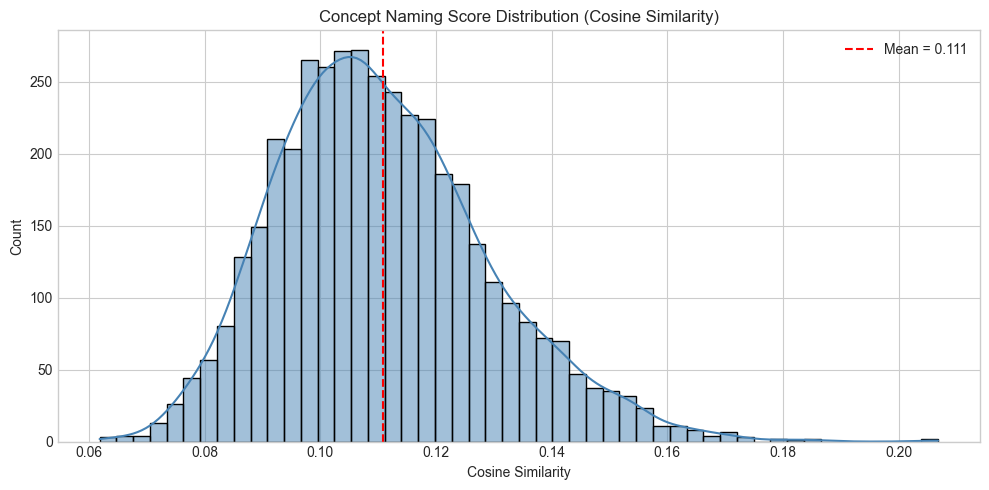

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/concept_scores_dist.png


In [16]:
# 5.1 Concept Naming Score Distribution
scores_array = [v['score'] for v in concept_names.values()]
plot_concept_score_distribution(scores_array, FIGURES_DIR / 'concept_scores_dist.png')

# Also display inline
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(scores_array, bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(np.mean(scores_array), color='red', linestyle='--', label=f'Mean = {np.mean(scores_array):.3f}')
ax.set_title('Concept Naming Score Distribution (Cosine Similarity)')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "concept_scores_dist.png"}')

18:31:12 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:31:12 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:31:12 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:31:12 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:31:12 | INFO | Saved per-seed metrics to /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/per_seed_metrics.png
18:31:12 | INFO | Using cat

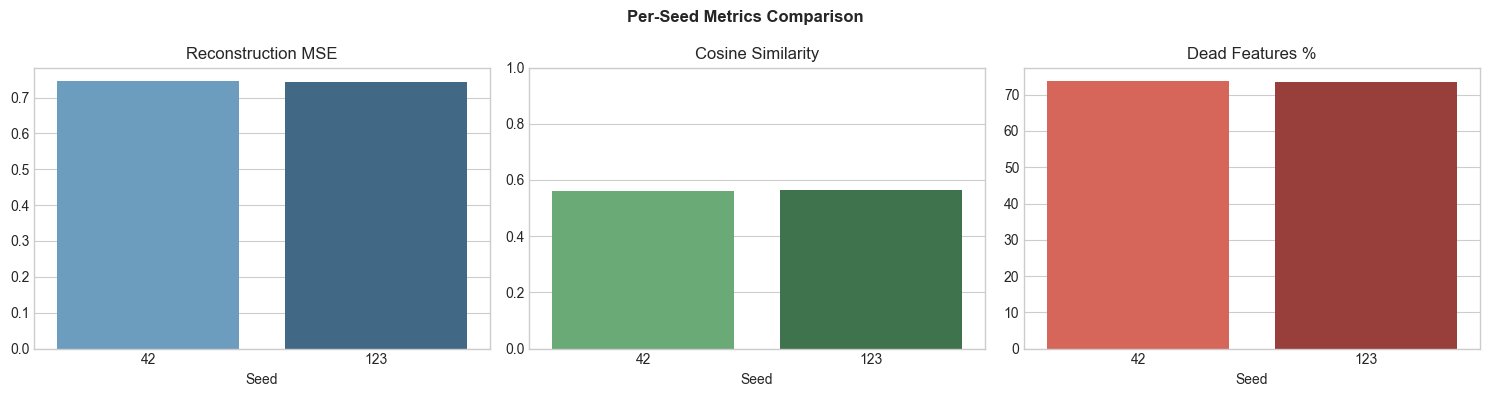

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/per_seed_metrics.png


In [17]:
# 5.2 Per-Seed Metrics Comparison (MSE and Dead Features)
plot_per_seed_metrics(per_seed_metrics, FIGURES_DIR / 'per_seed_metrics.png')

# Inline display
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
seeds_list = list(per_seed_metrics.keys())
mse_vals = [per_seed_metrics[s]['mse'] for s in seeds_list]
cosine_vals = [per_seed_metrics[s]['cosine'] for s in seeds_list]
dead_vals = [per_seed_metrics[s]['dead_features_pct'] for s in seeds_list]

sns.barplot(x=[str(s) for s in seeds_list], y=mse_vals, ax=axes[0], palette='Blues_d', hue=[str(s) for s in seeds_list], legend=False)
axes[0].set_title('Reconstruction MSE')
axes[0].set_xlabel('Seed')

sns.barplot(x=[str(s) for s in seeds_list], y=cosine_vals, ax=axes[1], palette='Greens_d', hue=[str(s) for s in seeds_list], legend=False)
axes[1].set_title('Cosine Similarity')
axes[1].set_xlabel('Seed')
axes[1].set_ylim(0, 1)

sns.barplot(x=[str(s) for s in seeds_list], y=dead_vals, ax=axes[2], palette='Reds_d', hue=[str(s) for s in seeds_list], legend=False)
axes[2].set_title('Dead Features %')
axes[2].set_xlabel('Seed')

fig.suptitle('Per-Seed Metrics Comparison', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "per_seed_metrics.png"}')

/var/folders/v6/8dp2_fyn1y525csqgb_j5ln00000gn/T/ipykernel_68442/1435046151.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jaccard_matrix = np.array(stability['jaccard_matrix'])
18:31:12 | INFO | Saved Jaccard heatmap to /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/jaccard_heatmap.png


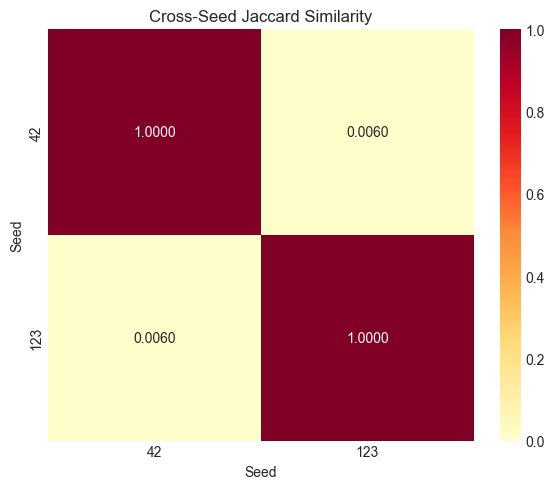

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/jaccard_heatmap.png


In [18]:
# 5.3 Jaccard Heatmap (Cross-Seed Stability)
jaccard_matrix = np.array(stability['jaccard_matrix'])
plot_jaccard_heatmap(jaccard_matrix, list(config.training.seeds), FIGURES_DIR / 'jaccard_heatmap.png')

# Inline display
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    jaccard_matrix,
    annot=True, fmt='.4f',
    xticklabels=[str(s) for s in config.training.seeds],
    yticklabels=[str(s) for s in config.training.seeds],
    cmap='YlOrRd', vmin=0, vmax=1, ax=ax
)
ax.set_title('Cross-Seed Jaccard Similarity')
ax.set_xlabel('Seed')
ax.set_ylabel('Seed')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "jaccard_heatmap.png"}')

18:31:12 | INFO | Saved sparsity summary to /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/sparsity_summary.png


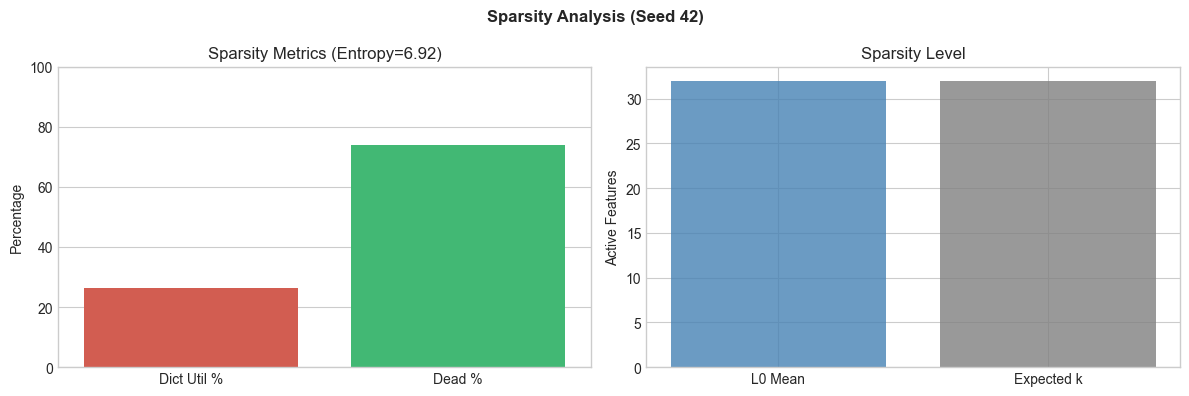

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/sparsity_summary.png


In [19]:
# 5.4 Sparsity Summary (primary seed)
primary_metrics = per_seed_metrics[config.training.primary_seed]
plot_sparsity_summary(
    dead_pct=primary_metrics['dead_features_pct'],
    utilization=primary_metrics['dict_utilization_pct'],
    entropy=primary_metrics['activation_entropy'],
    save_path=FIGURES_DIR / 'sparsity_summary.png',
)

# Inline display
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart
metrics_data = {
    'Dict Util %': primary_metrics['dict_utilization_pct'],
    'Dead %': primary_metrics['dead_features_pct'],
}
colors = ['#2ecc71' if v > 50 else '#e74c3c' for v in metrics_data.values()]
sns.barplot(x=list(metrics_data.keys()), y=list(metrics_data.values()), ax=axes[0],
            palette=colors, hue=list(metrics_data.keys()), legend=False)
axes[0].set_title(f'Sparsity Metrics (Entropy={primary_metrics["activation_entropy"]:.2f})')
axes[0].set_ylabel('Percentage')
axes[0].set_ylim(0, 100)

# Right: L0 distribution
axes[1].bar(['L0 Mean', 'Expected k'], [primary_metrics['l0_mean'], config.sae.k],
            color=['steelblue', 'gray'], alpha=0.8)
axes[1].set_title('Sparsity Level')
axes[1].set_ylabel('Active Features')

fig.suptitle(f'Sparsity Analysis (Seed {config.training.primary_seed})', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "sparsity_summary.png"}')

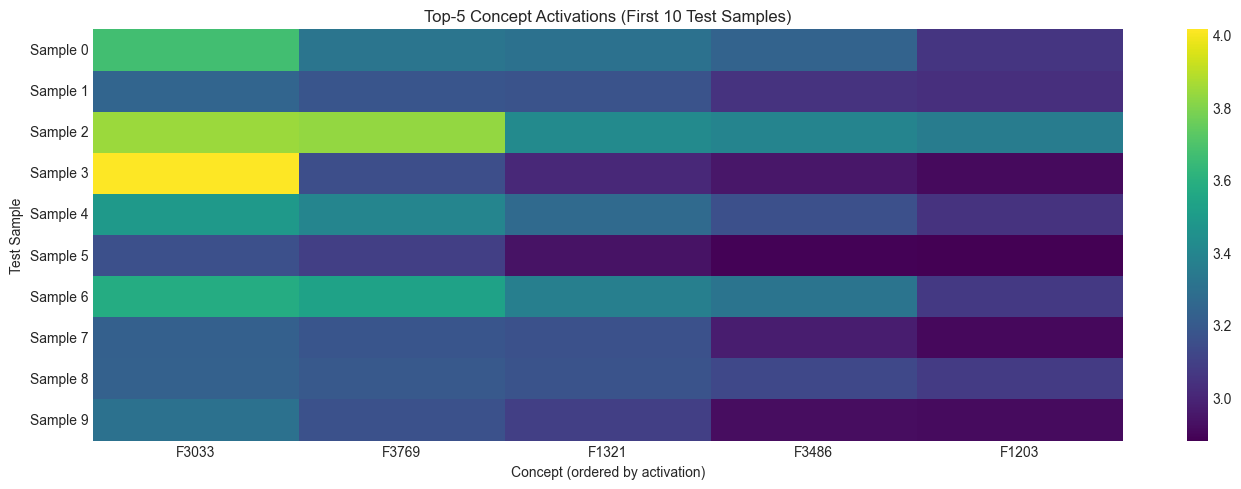

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/mock/figures/concept_activations_heatmap.png


In [20]:
# 5.5 Top Concept Activations per Sample (heatmap)
# Show top-k activated features for first 10 test samples
n_show = min(10, len(all_top_concepts))
k_show = config.explanation.explanation_top_n

activation_matrix = np.zeros((n_show, k_show))
concept_labels = []
for i in range(n_show):
    for j, (feat_id, act_val) in enumerate(all_top_concepts[i][:k_show]):
        activation_matrix[i, j] = act_val
        if i == 0:
            name = concept_names.get(str(feat_id), {}).get('name', f'F{feat_id}')
            concept_labels.append(name[:15])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    activation_matrix,
    cmap='viridis',
    xticklabels=concept_labels if concept_labels else True,
    yticklabels=[f'Sample {i}' for i in range(n_show)],
    ax=ax,
)
ax.set_title(f'Top-{k_show} Concept Activations (First {n_show} Test Samples)')
ax.set_xlabel('Concept (ordered by activation)')
ax.set_ylabel('Test Sample')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'concept_activations_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "concept_activations_heatmap.png"}')

## 5.6 Weights & Biases Integration Test

Tests the `tracking.py` module by logging pipeline metrics to W&B.
Set `WANDB_ENABLED = True` below to actually log (requires `wandb login`).

In [21]:
WANDB_ENABLED = True  # Set to False to skip W&B logging

if WANDB_ENABLED:
    from autoencoder.tracking import init_tracking, log_metrics, log_artifact, finish_tracking

    # Initialize a W&B run for this smoke test
    init_tracking("smoke-test-mock", {
        "project": "sae-concept-discovery",
        "seeds": list(config.training.seeds),
        "steps": config.sae.steps,
        "k": config.sae.k,
        "dict_size": config.sae.dict_size,
        "activation_dim": config.sae.activation_dim,
        "batch_size": config.sae.batch_size,
        "note": "mock data smoke test",
    })

    # Log per-seed metrics
    for seed, metrics in per_seed_metrics.items():
        log_metrics({
            f"seed_{seed}/mse": metrics['mse'],
            f"seed_{seed}/cosine": metrics['cosine'],
            f"seed_{seed}/l0_mean": metrics['l0_mean'],
            f"seed_{seed}/dead_pct": metrics['dead_features_pct'],
            f"seed_{seed}/entropy": metrics['activation_entropy'],
        })

    # Log stability
    log_metrics({
        "stability/mean_jaccard": stability['mean_jaccard'],
    })

    # Log concept naming stats
    log_metrics({
        "naming/mean_score": sum(scores_array) / len(scores_array),
        "naming/max_score": max(scores_array),
        "naming/min_score": min(scores_array),
    })

    # Log figures as artifacts
    for fig_path in sorted(FIGURES_DIR.glob('*.png')):
        log_artifact(fig_path, f"mock-{fig_path.stem}", "figure")

    # Log result JSONs as artifacts
    log_artifact(MOCK_RESULTS_DIR / 'concept_names.json', "mock-concept-names", "results")
    log_artifact(MOCK_RESULTS_DIR / 'stability_analysis.json', "mock-stability", "results")

    finish_tracking()
    print('W&B run completed. Check your dashboard at https://wandb.ai')
else:
    print('W&B logging skipped (WANDB_ENABLED = False)')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/marcantoniolopez/.netrc.
wandb: Currently logged in as: marcantoniolopez0 (marcantoniolopez0-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


18:31:14 | INFO | wandb tracking enabled: smoke-test-mock


wandb: WARNING Artifact "mock-concept_activations_heatmap" already exists with the same content. No new version will be created.


naming/max_score,▁
naming/mean_score,▁
naming/min_score,▁
seed_123/cosine,▁
seed_123/dead_pct,▁
seed_123/entropy,▁
seed_123/l0_mean,▁
seed_123/mse,▁
seed_42/cosine,▁
seed_42/dead_pct,▁
+4,...


W&B run completed. Check your dashboard at https://wandb.ai


## 6. Summary

Final verification of all generated outputs.

In [22]:
print('=' * 50)
print('  PIPELINE COMPLETED SUCCESSFULLY')
print('=' * 50)
print()

# Models
print('Models:')
for seed in config.training.seeds:
    model_dir = MOCK_MODELS_DIR / f'sae_seed{seed}'
    ae_path = model_dir / 'trainer_0' / 'ae.pt'
    if not ae_path.exists():
        ae_path = model_dir / 'ae.pt'
    size_mb = ae_path.stat().st_size / 1024 / 1024
    print(f'  sae_seed{seed}: {size_mb:.1f} MB')

# Results
print('\nResults:')
for name in ['concept_names.json', 'sample_explanations.json', 'stability_analysis.json']:
    path = MOCK_RESULTS_DIR / name
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f'  {name}: {size_kb:.1f} KB')
    else:
        print(f'  {name}: MISSING')

# Figures
print('\nFigures:')
for fig_path in sorted(FIGURES_DIR.glob('*.png')):
    size_kb = fig_path.stat().st_size / 1024
    print(f'  {fig_path.name}: {size_kb:.1f} KB')

print('\nNOTE: These results are from RANDOM data (non-convergent).')
print('On real data (IU X-Ray + BiomedCLIP) results will be meaningful.')

  PIPELINE COMPLETED SUCCESSFULLY

Models:
  sae_seed42: 16.0 MB
  sae_seed123: 16.0 MB

Results:
  concept_names.json: 1532.0 KB
  sample_explanations.json: 42.3 KB
  stability_analysis.json: 0.9 KB

Figures:
  concept_activations_heatmap.png: 55.2 KB
  concept_scores_dist.png: 59.0 KB
  jaccard_heatmap.png: 29.1 KB
  per_seed_metrics.png: 41.8 KB
  sparsity_summary.png: 22.6 KB

NOTE: These results are from RANDOM data (non-convergent).
On real data (IU X-Ray + BiomedCLIP) results will be meaningful.
